In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from zipfile import ZipFile
from urllib.request import urlretrieve

from IPython.display import Image

%matplotlib inline

In [2]:
def download_and_unzip(url, save_path):
    print(f"Downloading and extracting assests....", end="")

    # Downloading zip file using urllib package.
    urlretrieve(url, save_path)

    try:
        # Extracting zip file using the zipfile package.
        with ZipFile(save_path) as z:
            # Extract ZIP file contents in the same directory.
            z.extractall(os.path.split(save_path)[0])

        print("Done")

    except Exception as e:
        print("\nInvalid file.", e)

In [3]:
URL = r"https://www.dropbox.com/s/rys6f1vprily2bg/opencv_bootcamp_assets_NB2.zip?dl=1"

asset_zip_path = os.path.join(os.getcwd(), f"opencv_bootcamp_assets_NB2.zip")

# Download if assest ZIP does not exists. 
if not os.path.exists(asset_zip_path):
    download_and_unzip(URL, asset_zip_path)

[[  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0

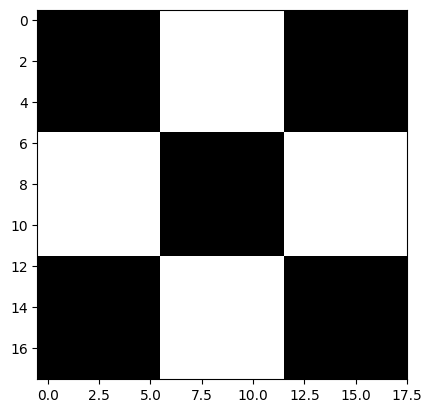

In [4]:
# Read image as grayscale
cb_img = cv2.imread("checkerboard_18x18.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(cb_img, cmap = "gray")

print(cb_img)

In [5]:
#print the second white colored box
print(cb_img[6:11,0:6])

[[255 255 255 255 255 255]
 [255 255 255 255 255 255]
 [255 255 255 255 255 255]
 [255 255 255 255 255 255]
 [255 255 255 255 255 255]]


In [6]:
#modifying img pixels
cb_img_modified = cb_img

cb_img_modified[7:11, 7:11] = 200

[[  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0 200 200 200 200   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0 200 200 200 200   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0 200 200 200 200   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0 200 200 200 200   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0

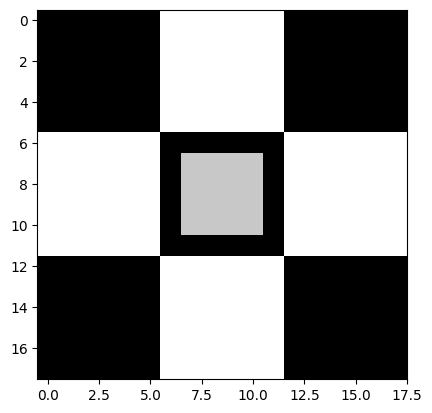

In [7]:
plt.imshow(cb_img_modified, cmap = "gray")
print(cb_img_modified)

# Cropping Image

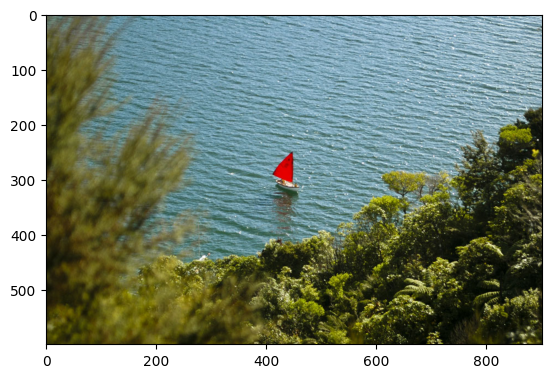

In [8]:
img_NZ_bgr = cv2.imread("New_Zealand_Boat.jpg", cv2.IMREAD_COLOR)
img_NZ_rgb = img_NZ_bgr[:,:,::-1]
plt.imshow(img_NZ_rgb)

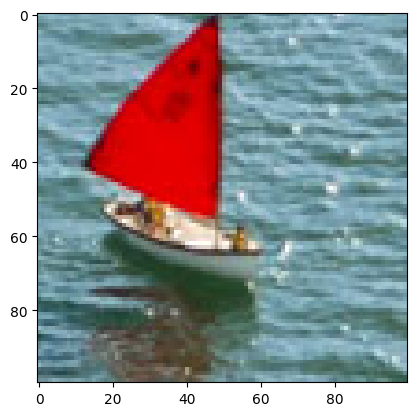

In [9]:
cropped_region = img_NZ_rgb[250:350, 400:500]
plt.imshow(cropped_region)

# Resizing images

## Method 1: Resizing using scaling factors fx and fy

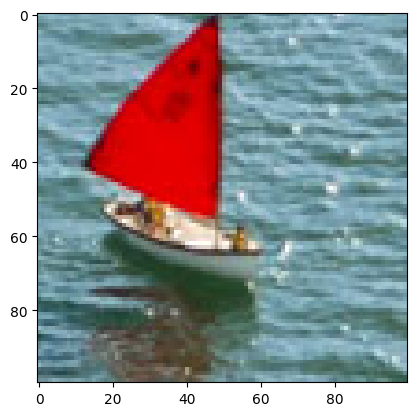

In [20]:
resized_cropped_region_2x = cv2.resize(cropped_region, None, fx = 2, fy =2)
plt.imshow(resized_cropped_region)

## method  2: Specifying exact size of output image

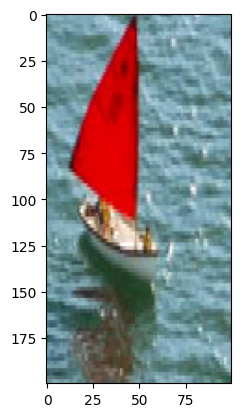

In [21]:
desired_width = 100
desired_height = 200
dim = (desired_width, desired_height)
resized_cropped_region = cv2.resize(cropped_region, dsize = dim, interpolation = cv2.INTER_AREA)
plt.imshow(resized_cropped_region)

## method 3: Resize while maintaining aspect ratio

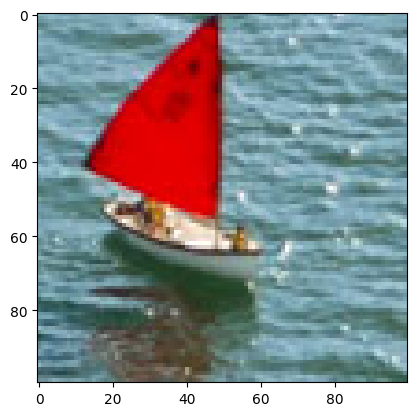

In [22]:
desired_width = 100
# Scaling factor should b esamne , fx = fy
scaling_factor = desired_width / cropped_region.shape[1]
desired_height = int(cropped_region.shape[0]*scaling_factor)
dim = (desired_width, desired_height)

resized_cropped_region = cv2.resize(cropped_region, dsize = dim, interpolation = cv2.INTER_AREA)

plt.imshow(resized_cropped_region)

# saving to drive and showing using the Ipython

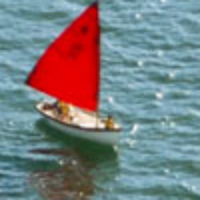

In [23]:
resized_cropped_region_2x = resized_cropped_region_2x[:,:,::-1]
cv2.imwrite("resized_cropped_region_2x.png",resized_cropped_region_2x)
Image(filename = "resized_cropped_region_2x.png")

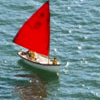

In [24]:
cropped_region = cropped_region[:,:,::-1]
cv2.imwrite("cropped_region.png", cropped_region)
Image(filename = "cropped_region.png")

Text(0.5, 1.0, 'Origional')

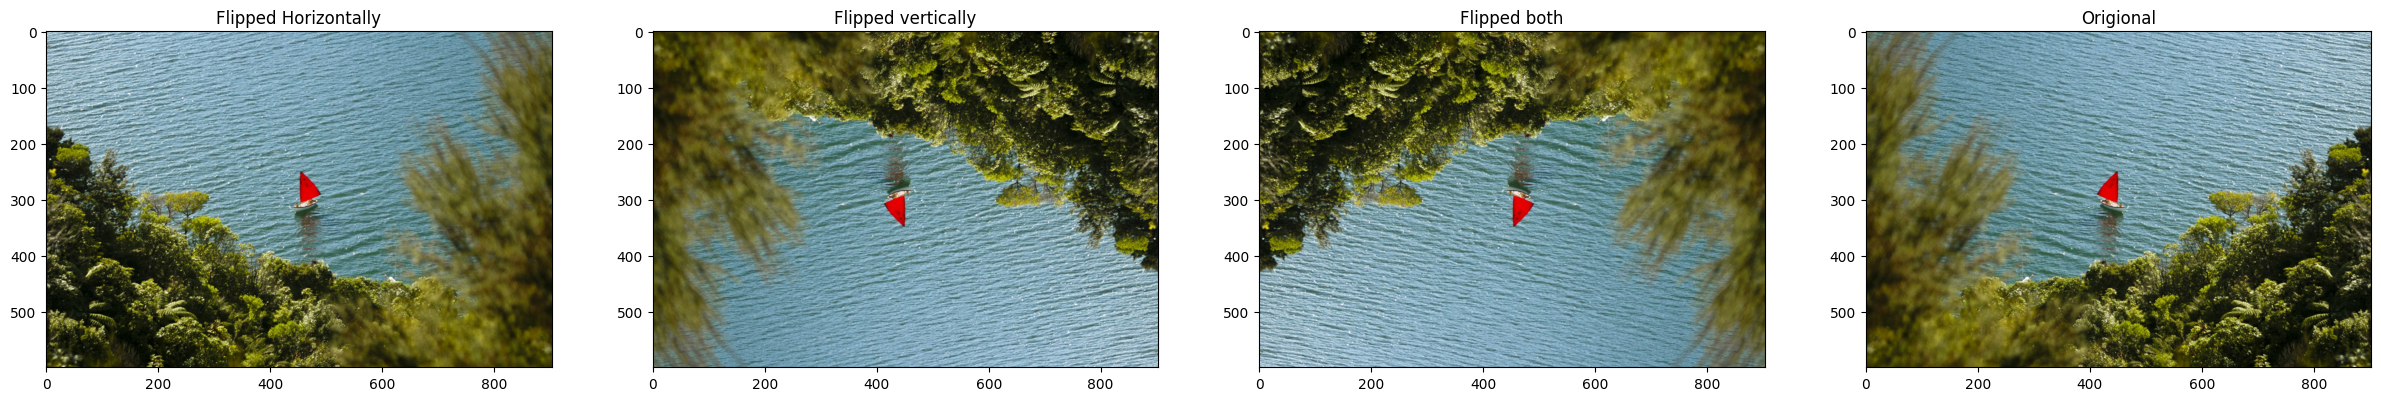

In [29]:
img_NZ_flipped_horizontally = cv2.flip(img_NZ_rgb, 1)
img_NZ_flipped_vertically = cv2.flip(img_NZ_rgb, 0)
img_NZ_flipped_both = cv2.flip(img_NZ_rgb, -1)

plt.figure(figsize = [30,7])

plt.subplot(141); plt.imshow(img_NZ_flipped_horizontally); plt.title("Flipped Horizontally")
plt.subplot(142); plt.imshow(img_NZ_flipped_vertically); plt.title("Flipped vertically")
plt.subplot(143); plt.imshow(img_NZ_flipped_both); plt.title("Flipped both")
plt.subplot(144); plt.imshow(img_NZ_rgb); plt.title("Origional")
